<a href="https://colab.research.google.com/github/BPerkins98/homework/blob/main/Homework4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Samples: (569, 30)
Targets: (569,)
Training samples: (426, 30)
Testing samples: (143, 30)
Accuracy: 0.951048951048951
Confusion Matrix:
 [[44  6]
 [ 1 92]]
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.88      0.93        50
           1       0.94      0.99      0.96        93

    accuracy                           0.95       143
   macro avg       0.96      0.93      0.94       143
weighted avg       0.95      0.95      0.95       143



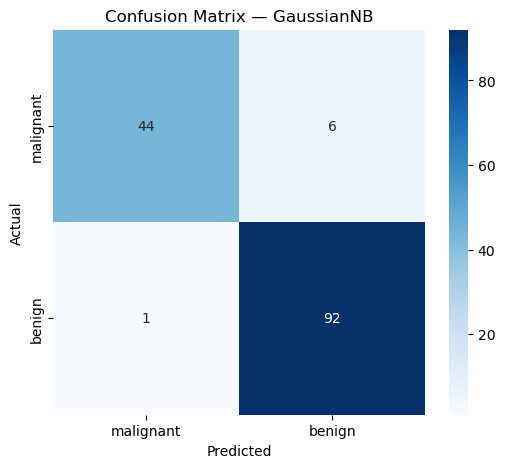

K-Fold Cross-Validation Scores: [0.96491228 0.9122807  0.94736842 0.89473684 0.96491228 0.94736842
 0.96491228 0.89473684 0.96491228 0.92857143]
Mean Accuracy: 0.9384711779448622

Comparing Multiple Models:
GaussianNB: Mean Accuracy = 0.9385
KNeighborsClassifier: Mean Accuracy = 0.9279
LogisticRegression: Mean Accuracy = 0.9508
SVC: Mean Accuracy = 0.9192


In [ ]:
# Ex 15.17 Binary Classification with the Breast Cancer Dataset

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------
# 1. Loading the Dataset
# ---------------------------------------------------------
breast_cancer = load_breast_cancer()

# ---------------------------------------------------------
# 2. Checking the Sample and Target Sizes
# ---------------------------------------------------------
print("Samples:", breast_cancer.data.shape)
print("Targets:", breast_cancer.target.shape)

# ---------------------------------------------------------
# 3. Splitting the Data for Training and Testing
# ---------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    breast_cancer.data,
    breast_cancer.target,
    test_size=0.25,
    random_state=11
)

# ---------------------------------------------------------
# 4. Training and Testing Set Sizes
# ---------------------------------------------------------
print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

# ---------------------------------------------------------
# 5. Creating the Model (GaussianNB)
# ---------------------------------------------------------
nb = GaussianNB()

# ---------------------------------------------------------
# 6. Training the Model
# ---------------------------------------------------------
nb.fit(X_train, y_train)

# ---------------------------------------------------------
# 7. Predicting
# ---------------------------------------------------------
predicted = nb.predict(X_test)

# ---------------------------------------------------------
# 8. Estimator Method score
# ---------------------------------------------------------
print("Accuracy:", nb.score(X_test, y_test))

# ---------------------------------------------------------
# 9. Confusion Matrix
# ---------------------------------------------------------
conf_matrix = confusion_matrix(y_true=y_test, y_pred=predicted)
print("Confusion Matrix:\n", conf_matrix)

# ---------------------------------------------------------
# 10. Classification Report
# ---------------------------------------------------------
print("Classification Report:\n", classification_report(y_test, predicted))

# ---------------------------------------------------------
# 11. Visualizing the Confusion Matrix
# ---------------------------------------------------------
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=breast_cancer.target_names,
            yticklabels=breast_cancer.target_names)
plt.title("Confusion Matrix — GaussianNB")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ---------------------------------------------------------
# 12. K-Fold Cross-Validation
# ---------------------------------------------------------
kfold = KFold(n_splits=10, random_state=11, shuffle=True)

scores = cross_val_score(
    estimator=nb,
    X=breast_cancer.data,
    y=breast_cancer.target,
    cv=kfold
)

print("K-Fold Cross-Validation Scores:", scores)
print("Mean Accuracy:", scores.mean())

# ---------------------------------------------------------
# 13. Running Multiple Models to Find the Best One
# ---------------------------------------------------------
estimators = {
    'GaussianNB': nb,
    'KNeighborsClassifier': KNeighborsClassifier(),
    'LogisticRegression': LogisticRegression(
        solver='lbfgs',
        max_iter=10000
    ),
    'SVC': SVC(gamma='scale')
}

print("\nComparing Multiple Models:")
for name, estimator in estimators.items():
    cv_scores = cross_val_score(
        estimator=estimator,
        X=breast_cancer.data,
        y=breast_cancer.target,
        cv=kfold
    )
    print(f"{name}: Mean Accuracy = {cv_scores.mean():.4f}")
